# Practice 1: Part-of-Speech (POS) Tagger

This notebook implements a neural Part-of-Speech (POS) tagger using LSTMs.

The goal is to load a corpus in CoNLL-U format, process it, build a model in Keras to tag it, train it, and finally, use it to predict tags on new sentences.

---

## 1 Loading the Data

The first step is to read the data from the `CoNLL-U` file format.

This cell defines the `load_conllu_data` function, which is the heart of our data preprocessing.

* **Purpose**: It reads a `.conllu` file and transforms it into two parallel lists: one of sentences (lists of words) and another of tags (lists of UPOS tags).
* **Processing Logic**:
    * It iterates over each line in the file.
    * **Ignores Comments**: If the line starts with `#`, it's ignored.
    * **Handles Sentence Boundaries**: A blank line marks the end of a sentence. At this point, the accumulated `current_sentence` and `current_tags` are appended to the main lists.
    * **Ignores Special Tokens**: The code ignores "multiword" tokens (e.g., `19-20` "don't") and "empty nodes" (which have a dot in the ID, e.g., `1.1`).
    * **Extracts Data**: For a normal token line, it splits the line by the tab character `\t`. It then extracts:
        * `word` (FORM) from field 1 (index `[1]`).
        * `pos_tag` (UPOS) from field 3 (index `[3]`).
    * These are appended to the `current_` lists.

In [2]:
def load_conllu_data(filepath):
    """
    Loads and processes a CoNLL-U file, extracting sentences and their UPOS tags.
    """
    sentences = []
    tags = []
    current_sentence = []
    current_tags = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            #Ignore comments and empty lines that are not sentence separators
            if line.startswith('#'):
                continue
            
            # Blank line: indicates the end of a sentence
            elif line == '':
                if current_sentence:
                    sentences.append(current_sentence)
                    tags.append(current_tags)
                    current_sentence = []
                    current_tags = []
            
            #  Process a word line
            else:
                fields = line.split('\t')
                
                # Ignore multiword tokens 
                if '-' in fields[0] or '.' in fields[0]:
                    continue

                # Extract the word (FORM, index 1) and the PoS tag (UPOS, index 3)
                word = fields[1]
                pos_tag = fields[3]
                
                current_sentence.append(word)
                current_tags.append(pos_tag)

    if current_sentence:
        sentences.append(current_sentence)
        tags.append(current_tags)

    return sentences, tags

### Language Configuration and Loading

This cell prepares the notebook to be reusable for different languages.

* **`LANGUAGE_CONFIG`**: A dictionary that maps a language code ('en', 'es', 'pt', 'fa') to the paths of its respective `train`, `dev`, and `test` files. 
* **`SELECTED_LANGUAGE = 'fa'`**: This is where we select the language the rest of the notebook will work with. In this case, Persian (Farsi) has been chosen.
* **Data Loading**: The code uses the `SELECTED_LANGUAGE` variable to get the correct paths from the `LANGUAGE_CONFIG` dictionary and then calls the `load_conllu_data` function three times to load the training, development, and test sets.
* **Output**: The final `print` statements verify that the data has been loaded, showing the total number of sentences in each set and an example of the first sentence.

In [8]:
LANGUAGE_CONFIG = {
    'en': {
        'train': 'English/en_ewt-ud-train.conllu',
        'dev': 'English/en_ewt-ud-dev.conllu',
        'test': 'English/en_ewt-ud-test.conllu'
    },
    'es': {
        'train': 'Spanish/es_ancora-ud-train.conllu',
        'dev': 'Spanish/es_ancora-ud-dev.conllu',
        'test': 'Spanish/es_ancora-ud-test.conllu'
    },
    'pt': {
        'train': 'Portuguese/pt_porttinari-ud-train.conllu',
        'dev': 'Portuguese/pt_porttinari-ud-dev.conllu',
        'test': 'Portuguese/pt_porttinari-ud-test.conllu'
    },
    'fa': {
        'train': 'Persian/fa_perdt-ud-train.conllu',
        'dev': 'Persian/fa_perdt-ud-dev.conllu',
        'test': 'Persian/fa_perdt-ud-test.conllu'
    }
}

# ==================================================================
# SELECT LANGUAGE HERE
# ==================================================================
SELECTED_LANGUAGE = 'en'

# Get the paths for the selected language
try:
    paths = LANGUAGE_CONFIG[SELECTED_LANGUAGE]
    print(f"--- Model for: '{SELECTED_LANGUAGE}' ---")

    # --- # Load the data using the selected paths ---
    train_sents, train_tags = load_conllu_data(paths['train'])
    dev_sents, dev_tags = load_conllu_data(paths['dev'])
    test_sents, test_tags = load_conllu_data(paths['test'])
    
    print("\nLoading complete")
    print(f"Sentences for training: {len(train_sents)} example train sents {train_sents[8]}")
    print(f"tags: {train_tags[8]}")
    print(f"Sentences for dev: {len(dev_sents)} example dev sents {dev_sents[0]}")
    print(f"Sentences for test: {len(test_sents)} example test sents {test_sents[0]}")
    
except KeyError:
    print(f"Error: The language '{SELECTED_LANGUAGE}' is not in LANGUAGE_CONFIG.")
    exit()

--- Model for: 'en' ---

Loading complete
Sentences for training: 12544 example train sents ['Although', 'the', 'announcement', 'was', 'probably', 'made', 'to', 'show', 'progress', 'in', 'identifying', 'and', 'breaking', 'up', 'terror', 'cells', ',', 'I', 'do', "n't", 'find', 'the', 'news', 'that', 'the', 'Baathists', 'continue', 'to', 'penetrate', 'the', 'Iraqi', 'government', 'very', 'hopeful', '.']
tags: ['SCONJ', 'DET', 'NOUN', 'AUX', 'ADV', 'VERB', 'PART', 'VERB', 'NOUN', 'SCONJ', 'VERB', 'CCONJ', 'VERB', 'ADP', 'NOUN', 'NOUN', 'PUNCT', 'PRON', 'AUX', 'PART', 'VERB', 'DET', 'NOUN', 'SCONJ', 'DET', 'PROPN', 'VERB', 'PART', 'VERB', 'DET', 'ADJ', 'NOUN', 'ADV', 'ADJ', 'PUNCT']
Sentences for dev: 2001 example dev sents ['From', 'the', 'AP', 'comes', 'this', 'story', ':']
Sentences for test: 2077 example test sents ['What', 'if', 'Google', 'Morphed', 'Into', 'GoogleOS', '?']


## 2. Text Vectorization: Creating the Dictionaries

The first step in preparing the data for the LSTM model is to convert our text-based sentences and tags into numerical sequences. Neural networks can only process numbers, so we need a consistent way to map each word and each tag to a unique integer ID.

For this task, we'll use Keras's modern `TextVectorization` layer. We will create two separate instances of this layer: one for the input words (`word_vectorizer`) and one for the output tags (`tag_vectorizer`).

The process involves two main stages:
1.  **Configuration**: We initialize the `TextVectorization` layer with `output_mode='int'` to ensure it produces sequences of integer IDs (e.g., "Google is nice" -> `[2, 3, 42]`). We also set `output_sequence_length=128` to enforce that all sequences are padded or truncated to a fixed length, which is a requirement for the model.
2.  **Adaptation**: We then call the `.adapt()` method on our training data. This step builds the internal vocabulary for each vectorizer. It analyzes all the words (or tags) in the training set and assigns a unique integer to each one. This ensures our "dictionaries" are based only on the data the model is allowed to learn from.


#### Code Explanation: Vectorization and Adaptation

This cell implements the vectorization process described above.

* **`MAX_LEN = 128`**: This global constant defines the maximum sentence length. This decision is based on the assignment instructions, which allow ignoring or truncating longer sentences to simplify processing.
* **`create_and_adapt_vectorizer`**: This helper function encapsulates the process of creating a vectorizer, setting its configuration (`output_mode`, `output_sequence_length`, `standardize`), and adapting it to the data.
* **`standardize` Decisions**:
    * `word_vectorizer`: Uses `standardize="lower"`. This converts all words to lowercase, reducing the vocabulary size (e.g., "Google" and "google" map to the same ID). It also keeps punctuation.
    * `tags_vectorizer`: Uses `standardize='lower_and_strip_punctuation'`. This is an unusual choice, as UPOS tags are canonically uppercase (e.g., 'NOUN', 'VERB'). However, the code is consistent: it creates a vocabulary of lowercase tags (as seen in the output `tags_vectorizer ['', '[UNK]', 'noun', ...]`), and the model will learn to predict these lowercase tags.
* **`adapt()`**: The `adapt` method is called *only* on the `train_sents` and `train_tags` data. This is crucial to prevent "data leakage", the model must not know about any words or tags that only appear in the development or test sets.
* **Flattening and Transformation**:
    * The `TextVectorization` layer expects a flat list of strings, not a list of lists. Therefore, the code "flattens" the sentences by joining the words with spaces (e.g., `['Google', 'is']` -> `'Google is'`).
    * Finally, the adapted vectorizers are called as functions to transform all datasets (train, dev, test), converting them from lists of strings to numerical ID tensors (`X_train`, `y_train`, etc.).

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

MAX_LEN = 128

def create_and_adapt_vectorizer(sentences, standardize, max_len=MAX_LEN):

    vectorizer = TextVectorization(
        output_mode='int',
        output_sequence_length=max_len,
        standardize=standardize
    )

    print("\nSentences before flat", sentences[0])
    sentences_flat = [' '.join(sentence) for sentence in sentences]
    print("\nSentence after flat", sentences_flat[0])
    
    vectorizer.adapt(sentences_flat)
    
    vocab_size = len(vectorizer.get_vocabulary())
    
    print(f"\nAdaptation complete. Vocabulary size: {vocab_size}")
    
    return vectorizer, vocab_size


# Pass 'standardize="lower"' to the word vectorizer
word_vectorizer, WORD_VOCAB_SIZE = create_and_adapt_vectorizer(train_sents, standardize="lower")

# The tag vectorizer uses 'lower_and_strip_punctuation'
tags_vectorizer, TAGS_VOCAB_SIZE = create_and_adapt_vectorizer(train_tags, standardize='lower_and_strip_punctuation')

# Get the vocabulary string list
tags_vocab_list = tags_vectorizer.get_vocabulary()
print("tags_vectorizer",tags_vocab_list)

print(f"\nWe have successfully created a vectorizer with a vocabulary of {WORD_VOCAB_SIZE} words.")

print(f"\nWe have successfully created a vectorizer with a vocabulary of {TAGS_VOCAB_SIZE} tags.")

print("Vectorizing all data sets...")


# --- 1. Flatten the data from list of lists to list of strings ---
# The vectorizer layers expect a flat list of strings as input.
train_sents_flat = [' '.join(sentence) for sentence in train_sents]
train_tags_flat = [' '.join(tag_list) for tag_list in train_tags]

dev_sents_flat = [' '.join(sentence) for sentence in dev_sents]
dev_tags_flat = [' '.join(tag_list) for tag_list in dev_tags]

test_sents_flat = [' '.join(sentence) for sentence in test_sents]
test_tags_flat = [' '.join(tag_list) for tag_list in test_tags]


# --- 2. Use the vectorizers to transform the flattened data ---
# Now we call the vectorizers with the correct input format.
X_train = word_vectorizer(train_sents_flat)
y_train = tags_vectorizer(train_tags_flat)

X_dev = word_vectorizer(dev_sents_flat)
y_dev = tags_vectorizer(dev_tags_flat)

X_test = word_vectorizer(test_sents_flat)
y_test = tags_vectorizer(test_tags_flat)

print("Vectorization complete!")
print("\nShape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_dev:", X_dev.shape)
print("Shape of y_dev:", y_dev.shape)


print("X_train",X_train[0])
print("y_train",y_train[0])
print("X_test",X_test[0])
print("y_test",y_test[0])
print(TAGS_VOCAB_SIZE)


Sentences before flat ['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']

Sentence after flat Al - Zaman : American forces killed Shaikh Abdullah al - Ani , the preacher at the mosque in the town of Qaim , near the Syrian border .

Adaptation complete. Vocabulary size: 16656

Sentences before flat ['PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'PROPN', 'PUNCT', 'ADP', 'DET', 'ADJ', 'NOUN', 'PUNCT']

Sentence after flat PROPN PUNCT PROPN PUNCT ADJ NOUN VERB PROPN PROPN PROPN PUNCT PROPN PUNCT DET NOUN ADP DET NOUN ADP DET NOUN ADP PROPN PUNCT ADP DET ADJ NOUN PUNCT

Adaptation complete. Vocabulary size: 19
tags_vectorizer ['', '[UNK]', np.str_('noun'), np.str_('punct'), np.str_('verb'

## 3 Building the Model

Now that our data is in numerical format, we can build the neural network architecture.

#### Code Explanation: Model Architecture

This cell defines the model architecture using the Keras Functional API, which is one of the recommendations.

* **Functional API**: Instead of `model.add()`, this style explicitly connects layers, starting with an `Input` layer.
* **`Input`**: Defines the model's entry point. `shape=(MAX_LEN,)` means it expects sequences of length 128.
* **`Embedding`**: This is the first processing layer.
    * It takes the input IDs (vocabulary size `WORD_VOCAB_SIZE`) and maps them to dense vectors (embeddings) of size `EMBEDDING_DIM` (64).
    * **`mask_zero=True`**: This is a **critical** implementation decision. It tells the Embedding layer that the ID `0` (which `TextVectorization` uses for padding) should be ignored. This "mask" will be automatically propagated to subsequent layers (LSTM, TimeDistributed), ensuring the model does not train on or perform calculations over the padding tokens.
* **`Bidirectional(LSTM(...))`**: This is the core of the model, as suggested in the guide (the bidirectional architecture is an improvement over the simple LSTM).
    * `LSTM`: The recurrent layer that can capture sequential dependencies.
    * `Bidirectional`: Wraps the LSTM, allowing the model to process the sequence from left-to-right and right-to-left, then concatenating the results. This gives each word "context" from *both* directions, which is vital for disambiguating POS tags.
    * **`return_sequences=True`**: This is another **critical** decision. By default, an LSTM only returns the final state vector (the "summary" of the whole sentence). Setting this to `True` makes the LSTM return the full sequence of state vectors, one for each word. This is necessary because we need to make a prediction for *every* word, not just one for the whole sentence.
* **`TimeDistributed(Dense(...))`**: This is the output layer.
    * `Dense`: A normal dense layer with `TAGS_VOCAB_SIZE` (18) neurons and `softmax` activation. `softmax` converts the scores into a probability distribution, indicating the likelihood of the word belonging to each of the 18 tags.
    * **`TimeDistributed`**: This is a "wrapper". It tells Keras to apply the *same* `Dense` layer to *every time step* (to every word) in the output sequence from the LSTM. Without this, the `Dense` layer would try to predict a single label for the entire sequence.
* **`Model(...)`**: Finally, the model is instantiated by connecting the `inputs` to the final `outputs`.

### Code Explanation: Model Compilation

Before training, the model must be "compiled."

* **`model.compile`**: This method configures the model for training.
* **`optimizer='adam'`**: Adam is a robust and popular optimizer that generally works well without needing to tune the learning rate.
* **`loss='sparse_categorical_crossentropy'`**: This is the loss function. The choice of **"sparse"** is important. We use `sparse_categorical_crossentropy` because our `y_train` labels are simple integers (e.g., `[3, 2, 12, 5, ..._]`). If we had "one-hot" encoded our labels (e.g., `[[0,0,1,0...], [0,1,0,0...], ...]`), we would have used `categorical_crossentropy`. Using "sparse" saves memory and the conversion step.
* **`metrics=['accuracy']`**: We ask the model to report "accuracy" at each epoch. Since `mask_zero=True` is active, this accuracy metric will automatically ignore the padded tokens, giving us a true measure of performance on the real words.

### Code Explanation: Model Training

This cell initiates and manages the training process.

* **`EarlyStopping`**: This is a regularization technique.
    * **Purpose**: It monitors a metric (in this case, `val_accuracy`) and stops the training if the metric doesn't improve (`mode='max'`) after a set number of epochs (`patience=3`).
    * **`restore_best_weights=True`**: This is key. If the model trains for 6 epochs but the best `val_accuracy` occurred at epoch 4, this setting ensures that the model's weights are rolled back to those from epoch 4 at the end of training. This prevents the model from "overfitting" in the final epochs.
* **`model.fit`**: This command starts the training.
    * It passes the training data (`X_train`, `y_train`).
    * It specifies the maximum number of `EPOCHS` (50) and the `BATCH_SIZE` (64).
    * It provides the `validation_data` (`X_dev`, `y_dev`). The model will use this data to calculate `val_loss` and `val_accuracy`, which are the metrics the `EarlyStopping` callback monitors.
    * It passes the `early_stopping_callback_acc` to the `callbacks` list.


In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, Bidirectional, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.metrics import sparse_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping

EMBEDDING_DIM = 64
LSTM_UNITS = 64

# Training parameters
EPOCHS = 50
BATCH_SIZE = 64


#Define the Input layer
inputs = Input(shape=(MAX_LEN,), name='word_ids_input')

# The Embedding layer receives the 'inputs'
x = Embedding(
    input_dim=WORD_VOCAB_SIZE, 
    output_dim=EMBEDDING_DIM, 
    mask_zero=True, 
    name='word_embedding'
)(inputs)


# Bidirectional LSTM layer
x = Bidirectional(
    LSTM(
        units=LSTM_UNITS, 
        return_sequences=True,
        name='bidirectional_lstm_1'
    )
)(x)


# Output Layer
outputs = TimeDistributed(
    Dense(units=TAGS_VOCAB_SIZE, activation='softmax'), 
    name='pos_tag_output'
)(x)

# Create the final Model
model = Model(inputs=inputs, outputs=outputs, name='pos_tagger_model_v2_bidirectional')

model.summary()



# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)




# Create an instance of the callback
early_stopping_callback_acc = EarlyStopping(
    monitor='val_accuracy',   
    patience=3,               
    min_delta=0.001,          
    mode='max',               
    restore_best_weights=True  # Save the best model
)


# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping_callback_acc]
)


Model: "pos_tagger_model_v2_bidirectional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  1,065,984 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      2,451 │ bidirectional_2[… │
│ (TimeDistributed)   │                   │            │ not_equal_2[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,134,483 (4.33 MB)

 Trainable params: 1,134,483 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.5773 - loss: 1.4692 - val_accuracy: 0.8427 - val_loss: 0.5876
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.9164 - loss: 0.3202 - val_accuracy: 0.8980 - val_loss: 0.3500
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.9544 - loss: 0.1694 - val_accuracy: 0.9055 - val_loss: 0.3168
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.9667 - loss: 0.1196 - val_accuracy: 0.9102 - val_loss: 0.3092
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.9735 - loss: 0.0934 - val_accuracy: 0.9098 - val_loss: 0.3343
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9784 - loss: 0.0762 - val_accuracy: 0.9116 - val_loss: 0.3196
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.9826 - loss: 0.0623 - val_accuracy: 0.9104 - val_loss: 0.3509
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 117ms/step - accuracy: 0.9862 - loss: 0

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_and_train_model(
    word_vocab_size,
    tag_vocab_size,
    max_len,
    X_train, y_train, X_dev, y_dev,
    
    # Hyperparameters
    embedding_dim=64,
    lstm_units=64,
    learning_rate=0.001,
    epochs=50,
    batch_size=64,
    
    model_name="pos_tagger_model",
    save_path=None
):
    """
    Build, compile, and train a bidirectional LSTM model for PoS tagging.

    Args:
        word_vocab_size (int): Word vocabulary size.
        tag_vocab_size (int): Tag vocabulary size.
        max_len (int): Maximum sequence length.
        X_train, y_train, X_dev, y_dev: Training and validation data.
        embedding_dim (int): Embedding vector dimensions.
        lstm_units (int): Number of units in the LSTM layer.
        learning_rate (float): Learning rate for the Adam optimizer.
        epochs (int): Maximum number of training epochs.
        batch_size (int): Training batch size.
        model_name (str): Model name.
        save_path (str, optional): Path to save the final model (e.g., "my_model.keras").

    Returns:
        tuple: (trained_model, training_history)
    """
    
    print(f"--- Building Model: {model_name} ---")
    print(f"Params: EMBEDDING_DIM={embedding_dim}, LSTM_UNITS={lstm_units}, LR={learning_rate}")
    
    # Architecture Construction
    # Define the Input layer
    inputs = Input(shape=(max_len,), name='word_ids_input')

    # The Embedding layer receives the 'inputs'
    x = Embedding(
        input_dim=word_vocab_size, 
        output_dim=embedding_dim, 
        mask_zero=True,
        name='word_embedding'
    )(inputs)

  
    # Bidirectional LSTM layer
    x = Bidirectional(
        LSTM(
            units=lstm_units, 
            return_sequences=True,
            name='bidirectional_lstm'
        )
    )(x)

    # Output Layer
    outputs = TimeDistributed(
        Dense(units=tag_vocab_size, activation='softmax'), 
        name='pos_tag_output'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name=model_name)
    model.summary()

    # Compilation
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    #  Callbacks
    early_stopping_callback = EarlyStopping(
        monitor='val_accuracy', 
        patience=3,          
        min_delta=0.001,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )

    # Training
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_dev, y_dev),
        callbacks=[early_stopping_callback]
    )
    
    # Save Model Opcional 
    if save_path:
        print(f"\nSaving the best model to: {save_path}")
        model.save(save_path)
        
    print(f"--- {model_name} training finished ---")
    
    return model, history

In [11]:
#Save Model
model.save('pos_tagger_best_model_English.keras')

In [23]:
params_base = {
    "embedding_dim": 64,
    "lstm_units": 64,
    "learning_rate": 0.001,
    "epochs": 50,
    "batch_size": 64,
    "model_name": "Base_Bidirectional_LSTM_EN_1",
    "save_path": "base_model.keras" 
}

# Llamamos a la función
model_base, history_base = build_and_train_model(
    WORD_VOCAB_SIZE, TAGS_VOCAB_SIZE, MAX_LEN,
    X_train, y_train, X_dev, y_dev,
    **params_base # Pasa todos los parámetros usando **
)

--- Construyendo Modelo: Base_Bidirectional_LSTM_EN_1 ---
Params: EMBEDDING_DIM=64, LSTM_UNITS=64, LR=0.001


Model: "Base_Bidirectional_LSTM_EN_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  1,065,984 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      2,451 │ bidirectional_4[… │
│ (TimeDistributed)   │                   │            │ not_equal_4[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,134,483 (4.33 MB)

 Trainable params: 1,134,483 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.5741 - loss: 1.4907 - val_accuracy: 0.8350 - val_loss: 0.5968
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.9144 - loss: 0.3241 - val_accuracy: 0.9002 - val_loss: 0.3371
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9550 - loss: 0.1672 - val_accuracy: 0.9089 - val_loss: 0.3089
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.9673 - loss: 0.1171 - val_accuracy: 0.9139 - val_loss: 0.2905
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.9744 - loss: 0.0914 - val_accuracy: 0.9145 - val_loss: 0.2933
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9792 - loss: 0.0739 - val_accuracy: 0.9139 - val_loss: 0.3115
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9832 - loss: 0.0606 - val_accuracy: 0.9146 - val_loss: 0.3173
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.

Gua

In [16]:
Testing nother Models and nother hiperparamiters
 aqui vamos a iterar entrenadno modelso con diferentes hiper parametros para ver el mejor resultado 

SyntaxError: invalid syntax (276758872.py, line 1)

In [26]:
#hiperparametors que se va iterar
hyperparameter_grid = [
    {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Base_Em_64_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 64,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Base_Em_128_lst_64_lr_0.001_bz_64"
    },
    {
        "embedding_dim": 64,
        "lstm_units": 128,
        "learning_rate": 0.001,
        "batch_size": 64,
        "model_name": "Base_Em_64_lst_128_lr_0.001_bz_64"
    },
        {
        "embedding_dim": 64,
        "lstm_units": 64,
        "learning_rate": 0.0005,
        "batch_size": 64,
        "model_name": "Base_Em_64_lst_64_lr_0.0005_bz_64"
    },
    {
        "embedding_dim": 128,
        "lstm_units": 128,
        "learning_rate": 0.0005,
        "batch_size": 32,
        "model_name": "Base_Em_128_lst_128_lr_0.001_bz_64"
    }
]

# --- 2. Preparar el almacenamiento de resultados ---
all_histories = {} 
best_val_accuracy = -1.0
best_model = None
best_model_name = ""

# --- 3. El Bucle de Experimentación ---
# (Asegúrate de que estas variables existen: X_train, y_train, X_dev, y_dev, WORD_VOCAB_SIZE, TAGS_VOCAB_SIZE, MAX_LEN)

for params in hyperparameter_grid:
    
    # Llama a tu función con los parámetros del experimento
    model, history = build_and_train_model(
        WORD_VOCAB_SIZE, TAGS_VOCAB_SIZE, MAX_LEN,
        X_train, y_train, X_dev, y_dev,
        embedding_dim=params["embedding_dim"],
        lstm_units=params["lstm_units"],
        learning_rate=params["learning_rate"],
        batch_size=params["batch_size"],
        epochs=EPOCHS,
        model_name=params["model_name"]
    )
    
    # Guarda el historial (el .history es el diccionario con los datos)
    all_histories[params["model_name"]] = history.history
    
    # Comprueba si este modelo es el mejor hasta ahora
    # history.history['val_accuracy'] es una lista de las precisiones de cada época
    current_best_val_acc = max(history.history['val_accuracy'])
    print(f"\n¡Model! {params['model_name']} with {current_best_val_acc:.4f} with val_accuracy")
    
    if current_best_val_acc > best_val_accuracy:
        print(f"\n¡This is the new model with best result! {params['model_name']} with {current_best_val_acc:.4f} with val_accuracy")
        best_val_accuracy = current_best_val_acc
        best_model = model # Guarda el objeto del modelo
        best_model_name = params["model_name"]
        
print(f"\n---  ---")
print(f"The best model was '{best_model_name}' with val_accurancy {best_val_accuracy*100:.2f}%")

# --- 4. Guardar el MEJOR modelo de todos en el disco ---
if best_model:
    best_model.save("best_overall_pos_tagger.keras")
    print("El mejor modelo general ha sido guardado en 'best_overall_pos_tagger.keras'")

--- Building Model: Base_Em_64_lst_64_lr_0.001_bz_64 ---
Params: EMBEDDING_DIM=64, LSTM_UNITS=64, LR=0.001


Model: "Base_Em_64_lst_64_lr_0.001_bz_64"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 64)   │  1,065,984 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 128, 128)  │     66,048 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      2,451 │ bidirectional_6[… │
│ (TimeDistributed)   │                   │            │ not_equal_6[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,134,483 (4.33 MB)

 Trainable params: 1,134,483 (4.33 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_ids_input      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 128, 128)  │  2,131,968 │ word_ids_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 128)       │          0 │ word_ids_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_10    │ (None, 128, 256)  │    263,168 │ word_embedding[0… │
│ (Bidirectional)     │                   │            │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_tag_output      │ (None, 128, 19)   │      4,883 │ bidirectional_10… │
│ (TimeDistributed)   │                   │            │ not_equal_10[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,400,019 (9.16 MB)

 Trainable params: 2,400,019 (9.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step - accuracy: 0.6556 - loss: 1.1902 - val_accuracy: 0.8704 - val_loss: 0.4678
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9281 - loss: 0.2646 - val_accuracy: 0.9050 - val_loss: 0.3204
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9596 - loss: 0.1464 - val_accuracy: 0.9110 - val_loss: 0.2911
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9703 - loss: 0.1045 - val_accuracy: 0.9131 - val_loss: 0.2924
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9764 - loss: 0.0815 - val_accuracy: 0.9129 - val_loss: 0.3124
Epoch 6/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9811 - loss: 0.0656 - val_accuracy: 0.9140 - val_loss: 0.3227
Epoch 7/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9848 - loss: 0.0530 - val_accuracy: 0.9129 - val_loss: 0.3240
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


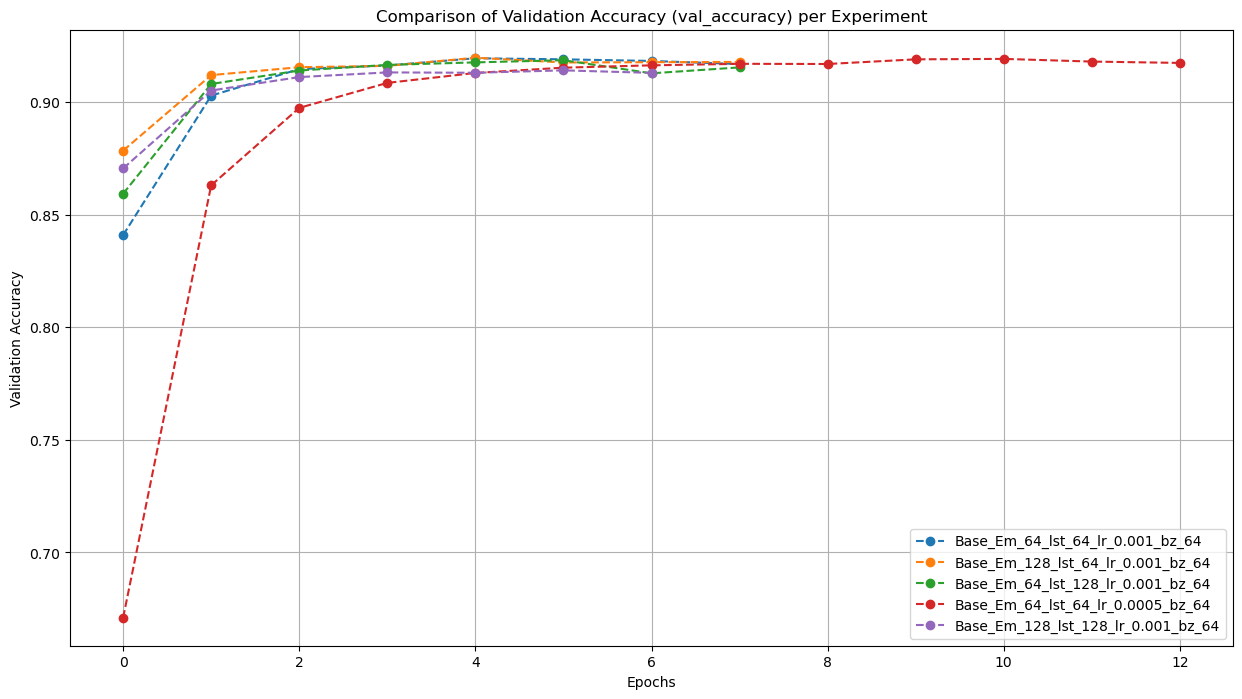

In [27]:
import matplotlib.pyplot as plt

# --- Plot Validation Accuracy ---
plt.figure(figsize=(15, 8))
plt.title("Comparison of Validation Accuracy (val_accuracy) per Experiment")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

for model_name, history_data in all_histories.items():
    # Plot the validation accuracy for each model
    plt.plot(history_data['val_accuracy'], label=model_name, marker='o', linestyle='--')

plt.legend()  # Show the legend with model names
plt.grid(True)  # Add a background grid
plt.show()    # Display the plot


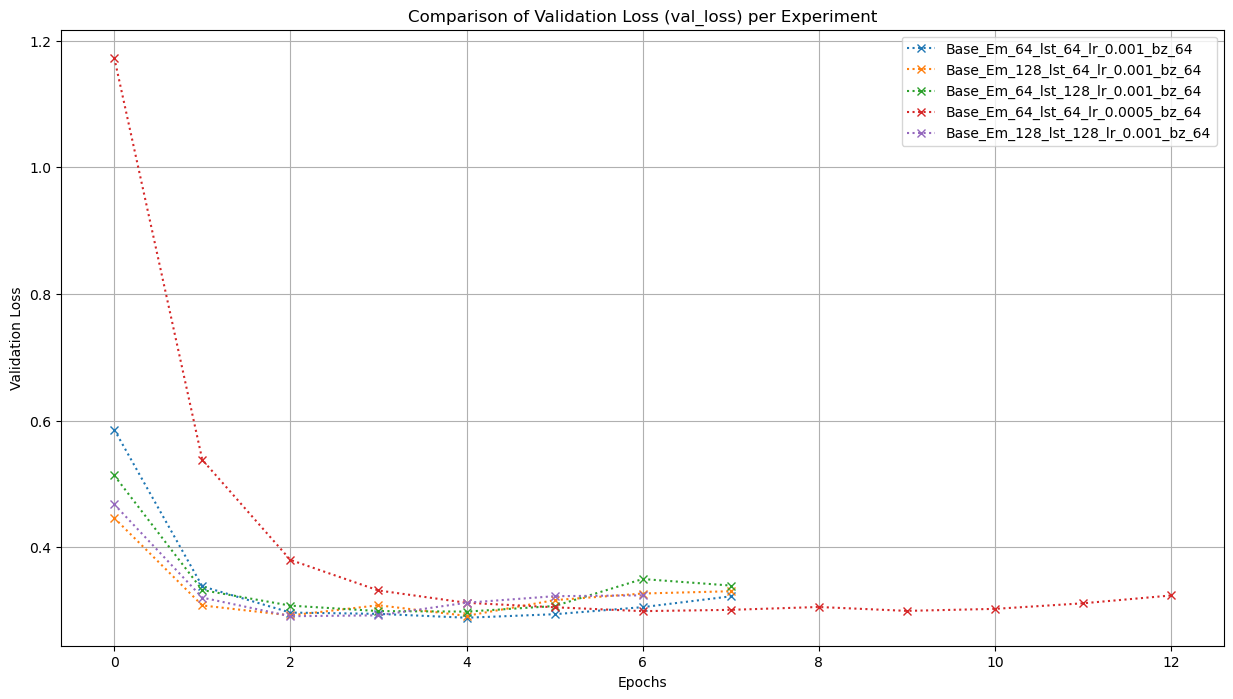

In [28]:
# --- Plot Validation Loss ---
plt.figure(figsize=(15, 8))
plt.title("Comparison of Validation Loss (val_loss) per Experiment")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")

for model_name, history_data in all_histories.items():
    # Plot the validation loss for each model
    plt.plot(history_data['val_loss'], label=model_name, marker='x', linestyle=':')

plt.legend()  # Show the legend with model names
plt.grid(True)  # Add a background grid
plt.show()    # Display the plot


## 0.4 Predicting on New Sentences

The final step is to use the trained model to tag completely new sentences.

#### Code Explanation: `predict_tags` Function

This cell defines a utility function `predict_tags` that encapsulates the entire prediction pipeline.

* **Purpose**: To take a sentence as a string, process it, and display the model's predictions word by word.
* **Steps**:
    1.  **Vectorize**: It takes the `sentence_string` and passes it to the `word_vectorizer` (which is already "adapted" or trained). The vectorizer lowercases it, tokenizes it, and transforms it into a padded ID tensor of length 128 (shape `[1, 128]`).
    2.  **Predict**: It calls `model.predict()` with that tensor. The model returns a tensor of probabilities with shape `[1, 128, 18]` (Batch, SeqLen, NumTags).
    3.  **`argmax`**: `np.argmax(predictions, axis=-1)` is applied on the last axis (the tag axis). For each of the 128 positions, it finds the *index* (the tag ID, from 0 to 17) that had the highest probability. The `[0]` at the end removes the batch dimension, leaving an array of shape `[128,]`.
    4.  **Decode**: The code gets the tag vocabulary (the list of strings, e.g., `['', '[UNK]', 'noun', ... ]`) from the `tags_vectorizer`.
    5.  **Display**: It iterates over the words from the original sentence (split by spaces) and uses the `predicted_ids` to look up the corresponding tag name in the `tags_vocab`.

In [17]:
import numpy as np


# 1. Get the tag vocabulary (the list of strings)
# ID 0 is '', ID 1 is '[UNK]', so the real vocabulary starts at index 2
tags_vocab = tags_vectorizer.get_vocabulary()

def predict_tags(sentence_string):
    """
    Takes a sentence (string), processes it with the model,
    and displays the predictions word by word.
    """
    print(f"--- Predicting for: ---\n{sentence_string}\n")
    
    # 0. Split the words to know how many there are
    words = sentence_string.split(' ')
    
    # 1. Convert the sentence (string) into an ID tensor (shape [1, 128])
    # The vectorizer expects a list of strings
    input_tensor = word_vectorizer([sentence_string])
    print("input_tensor",input_tensor)
    
    # 2. Get the model's predictions
    # The model returns probabilities (shape [1, 128, 18])
    predictions = model.predict(input_tensor)
    
    # 3. Find the ID of the tag with the highest probability for each token
    # We use np.argmax to get the winning IDs (shape [1, 128])
    predicted_ids = np.argmax(predictions, axis=-1)[0] # [0] to get the first (and only) batch
    print("predicted_ids",predicted_ids)
    
    # 4. Display the results
    print("--- Results: ---")
    for i in range(len(words)):
        word = words[i]
        tag_id = predicted_ids[i]
        tag_name = tags_vocab[tag_id]
        
        print(f"{word:<15} -> {tag_name}")

#### Code Explanation: Testing on New Sentences

This final cell puts everything together.

* **`new_test_sentences`**: A dictionary that stores lists of test sentences for each language.
* **Language Selection**: The code checks the `SELECTED_LANGUAGE` variable.
* **Prediction**: The `if` statement finds the key in the dictionary and then iterates over the list of sentences, calling `predict_tags` for each one.
* **Output**: The output shows the predictions for each test sentence.

In [18]:
# 1. Get the tag vocabulary
tags_vocab = tags_vectorizer.get_vocabulary()

# 2. Define the test sentences in a dictionary
new_test_sentences = {
    'en': [
        "Google is a nice search engine.", # [cite: 372]
        "I am writing this new sentence for the test.", # [cite: 375]
        "The university is in santiago.", # [cite: 377]
        "This model should tag punctuation correctly."
    ],
    'es': [
        "La universidad está en Santiago.",
        "Estoy escribiendo una nueva frase para la prueba.",
        "Google es un buen motor de búsqueda.",
        "telescopio comer", # [cite: 379]
        "Este modelo debería etiquetar la puntuación correctamente."
    ],
    'pt': [
        "Lisboa é a capital de Portugal.",
        "Eu estou escrevendo uma nova frase para o teste.",
        "Onde fica a estação de trem mais próxima?",
        "Este modelo funciona corretamente.", # [cite: 379]
    ],
    'fa': [
        "دانشگاه در تهران است", # The university is in Tehran
        "من در حال نوشتن یک جمله جدید هستم", # I am writing a new sentence
        "این یک آزمایش برای مدل است", # This is a test for the model
    ],
    
}

# 3. Select and test the sentences for the chosen language
if SELECTED_LANGUAGE in new_test_sentences:
    for sent in new_test_sentences[SELECTED_LANGUAGE]:
        predict_tags(sent)
else:
    print(f"No example sentences found for '{SELECTED_LANGUAGE}'.")

print("\n--- Process Complete ---")




--- Predicting for: ---
La universidad está en Santiago.

input_tensor tf.Tensor(
[[  5 711  54   8   1   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]], shape=(1, 128), dtype=int64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted_ids [ 4  2 12  3  2  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  8  8 